# Explorações — Rede Hopfield
Análises experimentais separadas do pipeline principal.

**Pré-requisito:** os arquivos em `outputs/treinamento/` já devem existir (gerados pelo `pipilinePrincipal.ipynb`).

---
## Avaliação Geral dos Experimentos

Compilação e análise de todos os experimentos executados em `pipilinePrincipal.ipynb`.  
Dados: Fujita (treino, 40.913 células) → Mathys (teste, 45.504 células avaliadas).  
6 classes: 1-Ast, 3-Ex, 4-In, 5-Mic, 6-Oli, 7-OPC.

---

### Ranking de configurações (melhores para piores)

| # | Config | n_padrões | acc % | f1_macro | f1_weighted |
|---|---|---|---|---|---|
| 1 | **nc=7, k=10**, β=8 | 42 | **83.69** | **0.8927** | **0.8511** |
| 2 | nc=20, k=5, β=8 | 120 | 82.34 | 0.8306 | 0.8396 |
| 3 | nc=20, k=3, β=8 | 120 | 79.20 | 0.7997 | 0.8095 |
| 4 | nc=30, k=1, β=8 | 180 | 70.44 | 0.7716 | 0.7193 |
| 5 | nc=20, k=1, β=8 | 120 | 70.29 | 0.7578 | 0.7172 |
| 6 | nc=10, k=1, β=8 | 60 | 66.79 | 0.7032 | 0.6784 |
| 7 | β×n_iters sweep (20 combos) | 60 | 66.79 | ~0.703 | ~0.678 |

---

### Achado 1 — Beta e n_iters são neutros com k=1

Todas as **20 combinações** de β ∈ {4, 8, 16, 32, 64} × n_iters ∈ {1, 2, 3, 5}  
produziram **exatamente acc=66.79%** com nc=10, k=1.

**Por quê?** Com k=1 cada protótipo é uma única célula do dataset, portanto ruidoso.  
A recuperação converge para o mesmo padrão binarizado independentemente da temperatura (β)  
ou do número de iterações — a rede está saturada e β não tem espaço para discriminar.  
β e n_iters só passam a ter efeito quando os protótipos são de melhor qualidade (k > 1).

---

### Achado 2 — k é o parâmetro mais impactante

| k | acc % | ganho sobre k=1 |
|---|---|---|
| 1 | 70.29 | — |
| 3 | 79.20 | +8.91 pp |
| 5 | 82.34 | +12.05 pp |
| 10 | 83.69 | +13.40 pp (com nc=7) |

k controla quantas células vizinhas ao centroide entram na média binarizada que forma o protótipo.  
k maior → protótipos mais "suaves", representando a região típica do cluster  
em vez de uma célula individual possivelmente atípica.  
Retornos decrescentes surgem a partir de k=5, mas o ganho marginal de k=10 ainda é positivo.

---

### Achado 3 — Protótipos compactos e ricos superam os densos e individuais

| Config | n_padrões | acc % | f1_macro |
|---|---|---|---|
| nc=7, k=10 | **42** | **83.69** | **0.8927** |
| nc=20, k=5 | 120 | 82.34 | 0.8306 |
| nc=30, k=1 | 180 | 70.44 | 0.7716 |

Menos protótipos, mas cada um construído a partir de mais células vizinhas,  
supera configurações com até 4× mais protótipos individuais.  
Hipótese: protótipos ruidosos competem entre si desnecessariamente e confundem a recuperação.

---

### Achado 4 — Gargalo: Inhibitory (cl.4) com precision cronicamente baixa

Em todos os experimentos, classe 4 apresenta:
- **Precision ≈ 0.41–0.47** (muitas células de outras classes atraídas para In)
- **Recall ≈ 0.97–0.98** (quase todas as células In reais são recuperadas)

Isso indica que o espaço de protótipos de In no Mathys **absorve células de outras classes**,  
especialmente Ex. A Frente 3 (scatter diff_Ex–In) confirma que vários genes que discriminam  
Ex de In no Fujita **não transferem** para o Mathys (genes discrepantes).

---

### Achado 5 — Recall de Ex (cl.3) estagnado em ~0.70

O recall de Ex não ultrapassa 0.70 em nenhuma configuração testada, apesar de:
- Ex representar 54% das células do Mathys (24.548 de 45.504)
- Precision de Ex ser consistentemente ~0.99–1.00

Muitas células Ex do Mathys são atraídas para protótipos de In (precision baixa de In = recall baixo de Ex).  
A Frente 4 (balanceamento) e as células 27/29 do pipeline (nc por classe + beta sweep)  
foram projetadas exatamente para atacar esse problema.

---

### Experimentos pendentes

| Experimento | Localização | Status |
|---|---|---|
| Varredura nc por classe (k=5) | `pipilinePrincipal.ipynb` cell 27 | ❌ não executado |
| Varredura beta com nc por classe (k=5) | `pipilinePrincipal.ipynb` cell 29 | ❌ não executado |
| Frente 4A — Subsampling no Fujita | `exploracoes.ipynb` | ❌ não executado |
| Frente 4B — nc proporcional ao Mathys | `exploracoes.ipynb` | ❌ não executado |

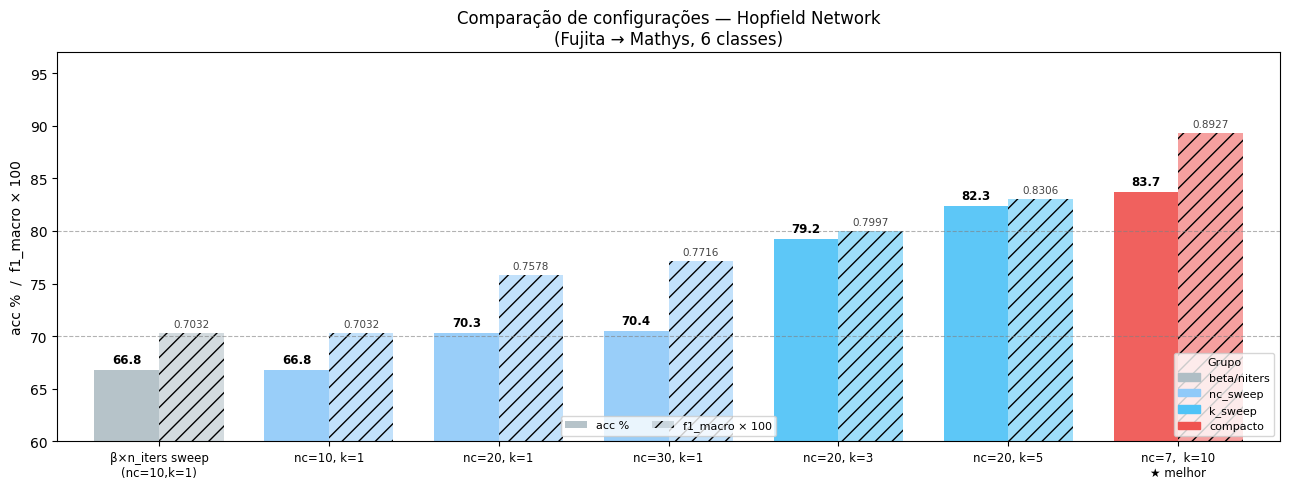


─── Melhor configuração: nc=7, k=10, β=8 ───
 classe        tipo  precision  recall   f1  support
      1  Astrocytes       1.00    1.00 1.00     2597
      3  Excitatory       0.99    0.70 0.82    24548
      4  Inhibitory       0.47    0.98 0.63     6420
      5   Microglia       0.83    1.00 0.91      485
      6 Oligodendro       0.99    1.00 0.99     9218
      7         OPC       1.00    1.00 1.00     2236

acc=83.69%  f1_macro=0.8927  f1_weighted=0.8511

Gargalos: Ex (cl.3) recall=0.70  |  In (cl.4) precision=0.47


In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

# ── Dados consolidados de todos os experimentos executados ────────
resultados = pd.DataFrame([
    # config_label,                  n_pad, acc,   f1_mac, f1_w,  grupo
    ('β×n_iters sweep\n(nc=10,k=1)', 60,   66.79, 0.7032, 0.678, 'beta/niters'),
    ('nc=10, k=1',                   60,   66.79, 0.7032, 0.678, 'nc_sweep'),
    ('nc=20, k=1',                  120,   70.29, 0.7578, 0.717, 'nc_sweep'),
    ('nc=30, k=1',                  180,   70.44, 0.7716, 0.719, 'nc_sweep'),
    ('nc=20, k=3',                  120,   79.20, 0.7997, 0.810, 'k_sweep'),
    ('nc=20, k=5',                  120,   82.34, 0.8306, 0.840, 'k_sweep'),
    ('nc=7,  k=10\n★ melhor',        42,   83.69, 0.8927, 0.851, 'compacto'),
], columns=['config', 'n_pad', 'acc', 'f1_macro', 'f1_w', 'grupo'])

# ── Paleta por grupo ──────────────────────────────────────────────
cores = {
    'beta/niters': '#b0bec5',
    'nc_sweep'   : '#90caf9',
    'k_sweep'    : '#4fc3f7',
    'compacto'   : '#ef5350',
}
bar_colors = [cores[g] for g in resultados['grupo']]

x = np.arange(len(resultados))
largura = 0.38

fig, ax = plt.subplots(figsize=(13, 5))

bars_acc = ax.bar(x - largura/2, resultados['acc'],    largura, color=bar_colors, alpha=0.92, label='acc %')
bars_f1  = ax.bar(x + largura/2, resultados['f1_macro']*100, largura, color=bar_colors, alpha=0.55, label='f1_macro × 100', hatch='//')

# Linha de referência
ax.axhline(70, color='gray', lw=0.8, ls='--', alpha=0.6)
ax.axhline(80, color='gray', lw=0.8, ls='--', alpha=0.6)

# Rótulos nos bars
for bar in bars_acc:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
for bar in bars_f1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{bar.get_height()/100:.4f}', ha='center', va='bottom', fontsize=7.5, color='#444')

# Legenda de grupos
patches = [mpatches.Patch(color=v, label=k) for k, v in cores.items()]
leg1 = ax.legend(handles=patches, loc='lower right', title='Grupo', fontsize=8, title_fontsize=8)
ax.add_artist(leg1)
ax.legend(loc='lower center', fontsize=8, ncol=2)

ax.set_xticks(x)
ax.set_xticklabels(resultados['config'], fontsize=8.5)
ax.set_ylabel('acc %  /  f1_macro × 100', fontsize=10)
ax.set_title('Comparação de configurações — Hopfield Network\n(Fujita → Mathys, 6 classes)', fontsize=12)
ax.set_ylim(60, 97)
ax.set_xlim(-0.6, len(resultados) - 0.4)
plt.tight_layout()
plt.show()

# ── Métricas por classe — melhor config (nc=7, k=10) ─────────────
print('\n─── Melhor configuração: nc=7, k=10, β=8 ───')
per_class = pd.DataFrame([
    (1, 'Astrocytes',    1.00, 1.00, 1.00, 2597),
    (3, 'Excitatory',   0.99, 0.70, 0.82, 24548),
    (4, 'Inhibitory',   0.47, 0.98, 0.63, 6420),
    (5, 'Microglia',    0.83, 1.00, 0.91, 485),
    (6, 'Oligodendro',  0.99, 1.00, 0.99, 9218),
    (7, 'OPC',          1.00, 1.00, 1.00, 2236),
], columns=['classe', 'tipo', 'precision', 'recall', 'f1', 'support'])
print(per_class.to_string(index=False))
print(f'\nacc=83.69%  f1_macro=0.8927  f1_weighted=0.8511')
print(f'\nGargalos: Ex (cl.3) recall=0.70  |  In (cl.4) precision=0.47')

## Setup — carregamento de dados

In [2]:
import sys, os, importlib
import numpy as np
import pandas as pd

SRC_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'src')
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import config, treinamento
import treinamento.carregador_dados_fujita as _cdf_mod
import treinamento.extrator_padroes        as _ep_mod
import treinamento.hopfield                as _hopfield_mod
import treinamento.avaliador_hopfield      as _av_mod
for mod in [_cdf_mod, _ep_mod, _hopfield_mod, _av_mod, config, treinamento]:
    importlib.reload(mod)

from config import PATH_LABELS_F, PATH_LABELS_M, PATH_SWEEP_F, OUT_TREINAMENTO, OUT_TOP_GENES
from treinamento import CarregadorDadosFujita, ExtratorPadroesSubcluster
from treinamento import ModernHopfieldNetwork, AvaliadorHopfield
from treinamento import ProjetorSWeP

# ── Fujita (padrões de treino) ──────────────────────────────────
path_matriz_f = os.path.join(OUT_TREINAMENTO, 'adataF_binarizado_alinhado_top5000.txt')
path_genes    = os.path.join(OUT_TOP_GENES,   'top5000_frequentes.csv')

carregador = CarregadorDadosFujita(
    path_matriz = path_matriz_f,
    path_genes  = path_genes,
    path_labels = PATH_LABELS_F,
    path_sweep  = PATH_SWEEP_F,
    n_genes     = 5000,
)
carregador.carregar()

# ── Projeção SWeeP → PCA (espaço de clusterização) ─────────────
projetor = ProjetorSWeP(n_features=5000)
projetor.usar_sweep_precomputado(carregador.Wswp).aplicar_pca()

# ── Mathys (conjunto de teste) ──────────────────────────────────
path_matriz_m = os.path.join(OUT_TREINAMENTO, 'adataM_binarizado_alinhado_top5000.txt')

W_mathys      = pd.read_csv(path_matriz_m).to_numpy(dtype=np.float32)
labels_mathys = np.loadtxt(PATH_LABELS_M, dtype=int)

print(f'Fujita  — W0: {carregador.W0.shape}, labels: {carregador.labels.shape}')
print(f'Mathys  — W:  {W_mathys.shape},      labels: {labels_mathys.shape}')
print(f'Projetor— Wswp: {projetor.Wswp.shape}')

[CarregadorDadosFujita] Carregando matriz: C:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\treinamento\adataF_binarizado_alinhado_top5000.txt


[CarregadorDadosFujita] Matriz carregada: (40913, 5000)
[CarregadorDadosFujita] W0 shape: (40913, 5000)
[CarregadorDadosFujita] Carregando genes: C:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\top_genes\top5000_frequentes.csv
[CarregadorDadosFujita] 5000 genes carregados
[CarregadorDadosFujita] Carregando rótulos: C:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\imputs\cell_types_binarioF.txt
[CarregadorDadosFujita] Rótulos shape: (40913,), tipos: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]
[CarregadorDadosFujita] Carregando SWeeP pré-computado: C:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\treinamento\matriz_reduzida_sweepF.csv


[CarregadorDadosFujita] Wswp shape: (40913, 600)
[CarregadorDadosFujita] Carregamento concluído: 40913 células, 5000 genes selecionados
[ProjetorSWeP] SWeeP pré-computado definido: (40913, 600)
[ProjetorSWeP] Aplicando PCA sem centralização...


[ProjetorSWeP] Wpc shape: (40913, 600)


Fujita  — W0: (40913, 5000), labels: (40913,)
Mathys  — W:  (45663, 5000),      labels: (45663,)
Projetor— Wswp: (40913, 600)


---
## Frente 1 — Varredura n_iters × beta
Com `n_iters=1` o beta não tem efeito (binarização cancela a temperatura do softmax).  
Com `n_iters>1` o vetor `x` entre iterações é contínuo, então beta passa a influenciar o refinamento.

In [3]:
CLASSES   = [1, 3, 4, 5, 6, 7]
NC_MELHOR = {1: 20, 3: 40, 4: 20, 5: 10, 6: 20, 7: 10}
K_MELHOR  = 5
N_ITERS_LIST = [1, 2, 3, 5]
BETAS        = [4, 8, 16, 32, 64]

# Padrões extraídos uma única vez
ext = ExtratorPadroesSubcluster(
    W0=carregador.W0, labels=carregador.labels,
    classes=CLASSES, nc=NC_MELHOR, seed=42, k=K_MELHOR,
)
ext.extrair(projetor.Wswp)
print(f'Padrões extraídos: {ext.padroes.shape[0]}\n')

resultados = []
for n_iters in N_ITERS_LIST:
    for beta in BETAS:
        rede = ModernHopfieldNetwork(beta=beta, n_iters=n_iters, binary=True, threshold=0.5)
        rede.store(ext.padroes)
        Wrec = rede.retrieve(W_mathys, batch_size=4096)

        av = AvaliadorHopfield(ext.padroes, CLASSES, meta=ext.meta)
        av.avaliar(Wrec, labels_mathys)
        resultados.append({
            'n_iters'  : n_iters,
            'beta'     : beta,
            'acc %'    : round(av.acuracia * 100, 2),
            'f1_macro' : round(av.f1_macro, 4),
            'f1_w'     : round(av.f1_weighted, 4),
            'taxa_rec %': round(av.taxa_reconstrucao * 100, 2),
        })
        print(f'n_iters={n_iters}  beta={beta:4d}  acc={av.acuracia*100:.2f}%  f1_macro={av.f1_macro:.4f}\n')

df_res = pd.DataFrame(resultados).sort_values('acc %', ascending=False)
print('\n── Ranking n_iters × beta ──')
print(df_res.to_string(index=False))

[ExtratorPadroesSubcluster] Classe 1: n=4366, KMeans(nc=20)...


[ExtratorPadroesSubcluster] Classe 3: n=9073, KMeans(nc=40)...


[ExtratorPadroesSubcluster] Classe 4: n=4567, KMeans(nc=20)...


[ExtratorPadroesSubcluster] Classe 5: n=1734, KMeans(nc=10)...


[ExtratorPadroesSubcluster] Classe 6: n=5762, KMeans(nc=20)...


...

[AvaliadorHopfield] Acurácia: 84.89% (n=45,504)
[AvaliadorHopfield] F1 macro=0.8425, F1 ponderado=0.8625
[AvaliadorHopfield] Taxa de reconstrução exata : 98.24%
[AvaliadorHopfield] Semelhança média ao protótipo: 0.9994
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2597
           3       1.00      0.73      0.84     24548
           4       0.51      0.97      0.67      6420
           5       0.39      1.00      0.56       485
           6       1.00      1.00      1.00      9218
           7       1.00      0.99      0.99      2236

    accuracy                           0.85     45504
   macro avg       0.81      0.95      0.84     45504
weighted avg       0.92      0.85      0.86     45504



n_iters=5  beta=  32  acc=84.89%  f1_macro=0.8425

[ModernHopfieldNetwork] 120 padrões armazenados (dim=5000, device=cpu)


[ModernHopfieldNetwork] Recuperação concluída: torch.Size([45663, 5000])
[AvaliadorHopfield] Mapeando padrões recuperados para classes...


[AvaliadorHopfield] Acurácia: 84.89% (n=45,504)
[AvaliadorHopfield] F1 macro=0.8425, F1 ponderado=0.8625
[AvaliadorHopfield] Taxa de reconstrução exata : 98.24%
[AvaliadorHopfield] Semelhança média ao protótipo: 0.9994
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2597
           3       1.00      0.73      0.84     24548
           4       0.51      0.97      0.67      6420
           5       0.39      1.00      0.56       485
           6       1.00      1.00      1.00      9218
           7       1.00      0.99      0.99      2236

    accuracy                           0.85     45504
   macro avg       0.81      0.95      0.84     45504
weighted avg       0.92      0.85      0.86     45504

n_iters=5  beta=  64  acc=84.89%  f1_macro=0.8425




── Ranking n_iters × beta ──
 n_iters  beta  acc %  f1_macro   f1_w  taxa_rec %
       1     4  84.89    0.8425 0.8625       98.20
       1     8  84.89    0.8425 0.8625       98.20
       1    16  84.89    0.8425 0.8625       98.20
       1    32  84.89    0.8425 0.8625       98.20
       1    64  84.89    0.8425 0.8625       98.20
       2     4  84.89    0.8425 0.8625       98.24
       2     8  84.89    0.8425 0.8625       98.24
       2    16  84.89    0.8425 0.8625       98.24
       2    32  84.89    0.8425 0.8625       98.24
       2    64  84.89    0.8425 0.8625       98.24
       3     4  84.89    0.8425 0.8626       98.34
       3     8  84.89    0.8425 0.8625       98.24
       3    16  84.89    0.8425 0.8625       98.24
       3    32  84.89    0.8425 0.8625       98.24
       3    64  84.89    0.8425 0.8625       98.24
       5     4  84.89    0.8425 0.8626       98.34
       5     8  84.89    0.8425 0.8625       98.24
       5    16  84.89    0.8425 0.8625       98.24
 

Melhor: n_iters=1, beta=4, acc=84.89%
[ModernHopfieldNetwork] 120 padrões armazenados (dim=5000, device=cpu)


[ModernHopfieldNetwork] Recuperação concluída: torch.Size([45663, 5000])
[AvaliadorHopfield] Mapeando padrões recuperados para classes...


[AvaliadorHopfield] Acurácia: 84.89% (n=45,504)
[AvaliadorHopfield] F1 macro=0.8425, F1 ponderado=0.8625
[AvaliadorHopfield] Taxa de reconstrução exata : 98.20%
[AvaliadorHopfield] Semelhança média ao protótipo: 0.9994
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2597
           3       1.00      0.73      0.84     24548
           4       0.51      0.97      0.67      6420
           5       0.39      1.00      0.56       485
           6       1.00      1.00      1.00      9218
           7       1.00      0.99      0.99      2236

    accuracy                           0.85     45504
   macro avg       0.81      0.95      0.84     45504
weighted avg       0.92      0.85      0.86     45504



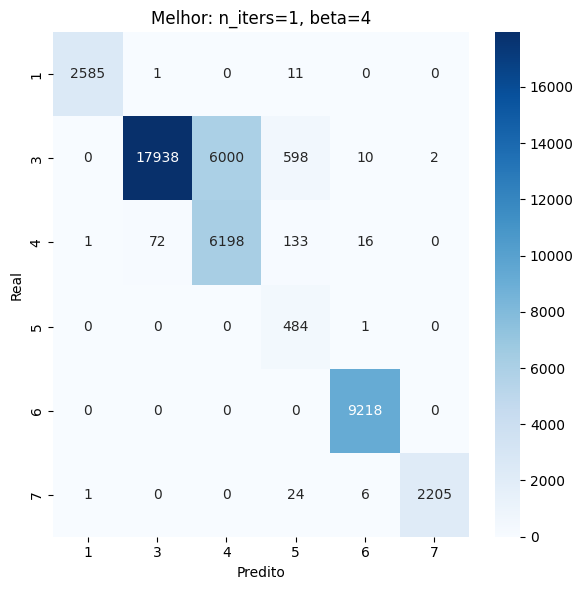

AvaliadorHopfield(
  padroes            = (120, 5000)
  classes            = [1, 3, 4, 5, 6, 7]
  nc                 = 10
  acuracia           = 84.89%
  f1_macro           = 0.8425
  f1_weighted        = 0.8625
  taxa_reconstrucao  = 98.20%
  semelhanca_media   = 0.9994
)

In [4]:
# Matriz de confusão da melhor combinação
melhor = df_res.iloc[0]
print(f"Melhor: n_iters={int(melhor.n_iters)}, beta={int(melhor.beta)}, acc={melhor['acc %']}%")

rede_best = ModernHopfieldNetwork(
    beta=int(melhor.beta), n_iters=int(melhor.n_iters), binary=True, threshold=0.5)
rede_best.store(ext.padroes)
Wrec_best = rede_best.retrieve(W_mathys, batch_size=4096)
av_best = AvaliadorHopfield(ext.padroes, CLASSES, meta=ext.meta)
av_best.avaliar(Wrec_best, labels_mathys)
av_best.plotar(titulo=f"Melhor: n_iters={int(melhor.n_iters)}, beta={int(melhor.beta)}")

---
## Frente 2 — Incluir classes 2 (Endothelial) e 8 (Pericytes)
Fujita: classe 2 = 188 células, classe 8 = 43 células.  
nc pequeno para não subdividir demais grupos já pequenos.

In [5]:
CLASSES_FULL = [1, 2, 3, 4, 5, 6, 7, 8]
NC_FULL = {1: 20, 2: 5, 3: 40, 4: 20, 5: 10, 6: 20, 7: 10, 8: 2}
K_FULL  = 5

print('Contagem de células por classe no Fujita:')
for cls in CLASSES_FULL:
    n = (carregador.labels == cls).sum()
    print(f'  Classe {cls}: {n} células  →  nc={NC_FULL[cls]}')
print(f'\nTotal padrões: {sum(NC_FULL[c] for c in CLASSES_FULL)}')

Contagem de células por classe no Fujita:
  Classe 1: 4366 células  →  nc=20
  Classe 2: 188 células  →  nc=5
  Classe 3: 9073 células  →  nc=40
  Classe 4: 4567 células  →  nc=20
  Classe 5: 1734 células  →  nc=10
  Classe 6: 5762 células  →  nc=20
  Classe 7: 1073 células  →  nc=10
  Classe 8: 43 células  →  nc=2

Total padrões: 127


[ExtratorPadroesSubcluster] Classe 1: n=4366, KMeans(nc=20)...


[ExtratorPadroesSubcluster] Classe 2: n=188, KMeans(nc=5)...


[ExtratorPadroesSubcluster] Classe 3: n=9073, KMeans(nc=40)...


[ExtratorPadroesSubcluster] Classe 4: n=4567, KMeans(nc=20)...


[ExtratorPadroesSubcluster] Classe 5: n=1734, KMeans(nc=10)...


[ExtratorPadroesSubcluster] Classe 6: n=5762, KMeans(nc=20)...


[ExtratorPadroesSubcluster] Classe 7: n=1073, KMeans(nc=10)...


[ExtratorPadroesSubcluster] Classe 8: n=43, KMeans(nc=2)...
[ExtratorPadroesSubcluster] Extração concluída: 127 padrões (8 classes)
[ModernHopfieldNetwork] 127 padrões armazenados (dim=5000, device=cpu)


[ModernHopfieldNetwork] Recuperação concluída: torch.Size([45663, 5000])
[AvaliadorHopfield] Mapeando padrões recuperados para classes...


[AvaliadorHopfield] Acurácia: 84.69% (n=45,663)
[AvaliadorHopfield] F1 macro=0.7351, F1 ponderado=0.8606
[AvaliadorHopfield] Taxa de reconstrução exata : 98.20%
[AvaliadorHopfield] Semelhança média ao protótipo: 0.9994
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2597
           2       0.79      0.44      0.57        68
           3       1.00      0.73      0.84     24548
           4       0.51      0.97      0.67      6420
           5       0.36      1.00      0.53       485
           6       1.00      1.00      1.00      9218
           7       1.00      0.99      0.99      2236
           8       0.84      0.18      0.29        91

    accuracy                           0.85     45663
   macro avg       0.81      0.79      0.74     45663
weighted avg       0.92      0.85      0.86     45663



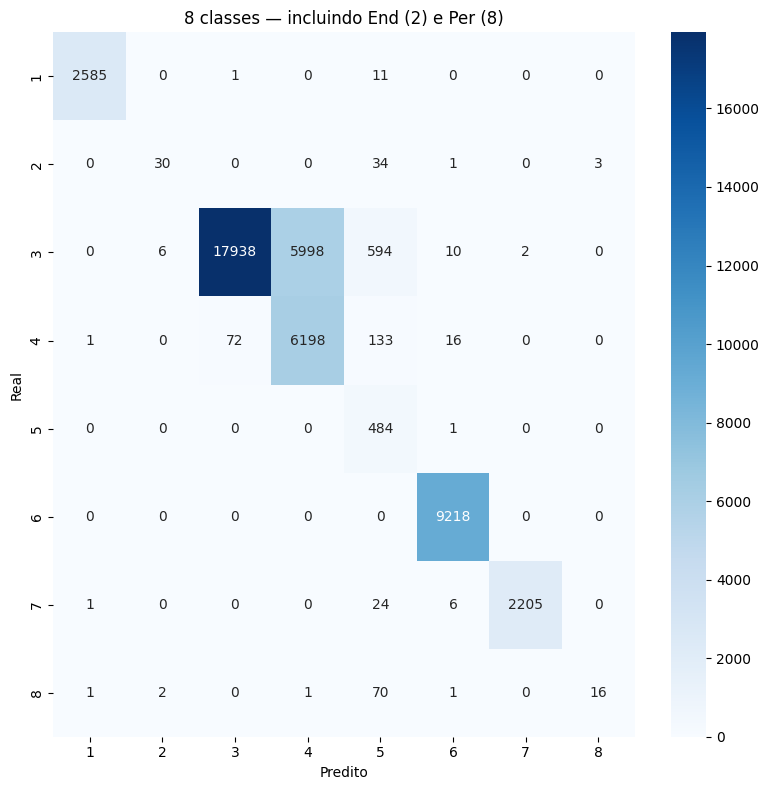

AvaliadorHopfield(
  padroes            = (127, 5000)
  classes            = [1, 2, 3, 4, 5, 6, 7, 8]
  nc                 = 10
  acuracia           = 84.69%
  f1_macro           = 0.7351
  f1_weighted        = 0.8606
  taxa_reconstrucao  = 98.20%
  semelhanca_media   = 0.9994
)

In [6]:
ext_full = ExtratorPadroesSubcluster(
    W0=carregador.W0, labels=carregador.labels,
    classes=CLASSES_FULL, nc=NC_FULL, seed=42, k=K_FULL,
)
ext_full.extrair(projetor.Wswp)

rede_full = ModernHopfieldNetwork(beta=8.0, n_iters=1, binary=True, threshold=0.5)
rede_full.store(ext_full.padroes)
Wrec_full = rede_full.retrieve(W_mathys, batch_size=4096)

av_full = AvaliadorHopfield(ext_full.padroes, CLASSES_FULL, meta=ext_full.meta)
av_full.avaliar(Wrec_full, labels_mathys)
av_full.plotar(titulo='8 classes — incluindo End (2) e Per (8)')

---
## Frente 3 — Fronteira Ex (3) vs In (4)
Compara quais genes discriminam Ex de In no Fujita (treino) e no Mathys (teste).  
Genes com alta diferença em Fujita mas baixa em Mathys indicam problemas de transferência entre datasets.

In [7]:
import matplotlib.pyplot as plt

# genes como array numpy para indexação posicional
# top5000_frequentes.csv tem colunas: gene (Ensembl ID), frequencia
genes = carregador.genes['gene'].values  # shape (5000,)

# ── Médias por classe ──────────────────────────────────────────
mask_ex_f = carregador.labels == 3
mask_in_f = carregador.labels == 4
mask_ex_m = labels_mathys == 3
mask_in_m = labels_mathys == 4

mean_ex_f = carregador.W0[mask_ex_f].mean(axis=0)  # (5000,)
mean_in_f = carregador.W0[mask_in_f].mean(axis=0)
mean_ex_m = W_mathys[mask_ex_m].mean(axis=0)
mean_in_m = W_mathys[mask_in_m].mean(axis=0)

diff_f = mean_ex_f - mean_in_f   # positivo → mais expresso em Ex no Fujita
diff_m = mean_ex_m - mean_in_m   # positivo → mais expresso em Ex no Mathys

print(f'Fujita  — Ex: {mask_ex_f.sum()} células, In: {mask_in_f.sum()} células')
print(f'Mathys  — Ex: {mask_ex_m.sum()} células, In: {mask_in_m.sum()} células')

Fujita  — Ex: 9073 células, In: 4567 células
Mathys  — Ex: 24548 células, In: 6420 células


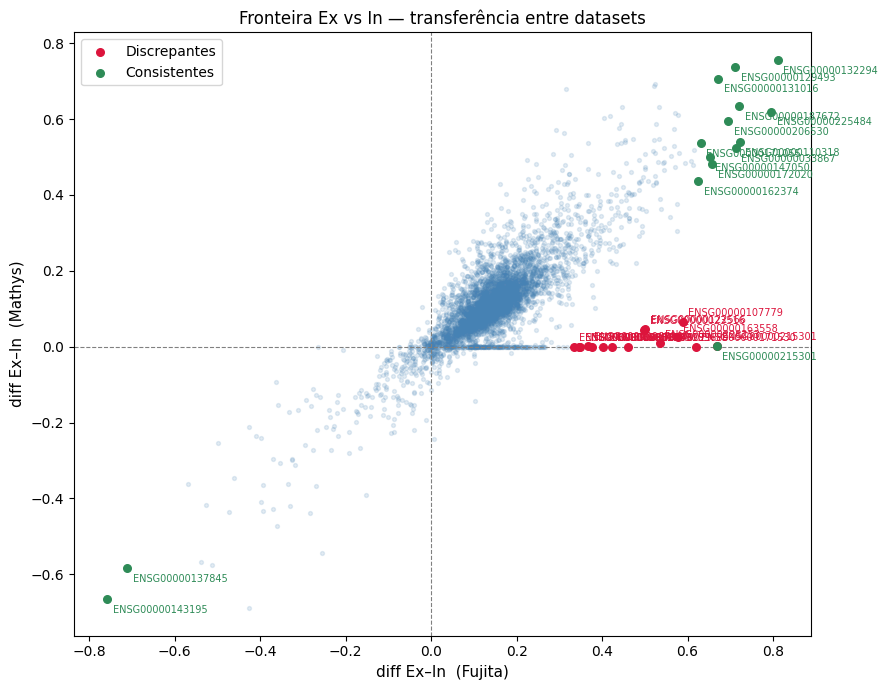


Top 15 genes discrepantes (funcionam em Fujita, não em Mathys):
  ENSG00000215301  diff_F=+0.669  diff_M=+0.002
  ENSG00000171530  diff_F=+0.619  diff_M=+0.000
  ENSG00000163558  diff_F=+0.577  diff_M=+0.025
  ENSG00000228253  diff_F=+0.534  diff_M=+0.009
  ENSG00000107779  diff_F=+0.589  diff_M=+0.066
  ENSG00000109689  diff_F=+0.462  diff_M=+0.000
  ENSG00000023516  diff_F=+0.499  diff_M=+0.044
  ENSG00000122566  diff_F=+0.500  diff_M=+0.047
  ENSG00000248079  diff_F=+0.422  diff_M=+0.000
  ENSG00000154305  diff_F=+0.403  diff_M=+0.000
  ENSG00000006576  diff_F=+0.377  diff_M=+0.000
  ENSG00000067167  diff_F=+0.367  diff_M=+0.002
  ENSG00000085224  diff_F=+0.347  diff_M=+0.000
  ENSG00000129515  diff_F=+0.347  diff_M=+0.000
  ENSG00000162631  diff_F=+0.333  diff_M=+0.000

Top 15 genes consistentes (discriminam em ambos os datasets):
  ENSG00000132294  diff_F=+0.811  diff_M=+0.757
  ENSG00000225484  diff_F=+0.796  diff_M=+0.620
  ENSG00000143195  diff_F=-0.757  diff_M=-0.666
  ENSG00

In [8]:
# ── Scatter diff_F vs diff_M ────────────────────────────────────
N_TOP = 15  # genes mais discrepantes a anotar

# Discrepância: alto |diff_F| mas baixo |diff_M| (ou sinal invertido)
discrepancia = np.abs(diff_f) - np.abs(diff_m)
idx_discr    = np.argsort(discrepancia)[::-1][:N_TOP]  # mais discrepantes

# Consistentes: alto |diff_F| E alto |diff_M| com mesmo sinal
consistencia = np.abs(diff_f) * np.sign(diff_f * diff_m)  # penaliza inversão de sinal
idx_consist  = np.argsort(np.abs(consistencia))[::-1][:N_TOP]

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(diff_f, diff_m, alpha=0.15, s=8, color='steelblue')
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.axvline(0, color='gray', lw=0.8, ls='--')

# Anotar genes discrepantes (vermelho)
for i in idx_discr:
    ax.annotate(genes[i], (diff_f[i], diff_m[i]),
                fontsize=7, color='crimson',
                xytext=(4, 4), textcoords='offset points')
ax.scatter(diff_f[idx_discr], diff_m[idx_discr], s=30, color='crimson', zorder=5, label='Discrepantes')

# Anotar genes consistentes (verde)
for i in idx_consist:
    ax.annotate(genes[i], (diff_f[i], diff_m[i]),
                fontsize=7, color='seagreen',
                xytext=(4, -10), textcoords='offset points')
ax.scatter(diff_f[idx_consist], diff_m[idx_consist], s=30, color='seagreen', zorder=5, label='Consistentes')

ax.set_xlabel('diff Ex–In  (Fujita)', fontsize=11)
ax.set_ylabel('diff Ex–In  (Mathys)', fontsize=11)
ax.set_title('Fronteira Ex vs In — transferência entre datasets', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nTop {N_TOP} genes discrepantes (funcionam em Fujita, não em Mathys):')
for i in idx_discr:
    print(f'  {genes[i]:15s}  diff_F={diff_f[i]:+.3f}  diff_M={diff_m[i]:+.3f}')

print(f'\nTop {N_TOP} genes consistentes (discriminam em ambos os datasets):')
for i in idx_consist:
    print(f'  {genes[i]:15s}  diff_F={diff_f[i]:+.3f}  diff_M={diff_m[i]:+.3f}')

---
## Frente 4 — Balanceamento entre datasets

Fujita (treino): Ex (cl.3) = 22% das células.  Mathys (teste): Ex = 54%.  
Essa discrepância pressiona o recall de Ex para baixo e a precision de In para baixo.

Duas estratégias testadas:
- **A — Subsampling no Fujita**: limitar cada classe a `MAX_CEL` células antes do KMeans.  
  Força o KMeans a explorar diversidade uniforme, sem Ex dominar o espaço de protótipos.
- **B — nc proporcional ao Mathys**: distribuir os protótipos proporcionalmente à frequência observada no conjunto de teste.

### Abordagem A — Subsampling das células do Fujita antes do KMeans

In [9]:
import sys, os, importlib
import numpy as np
import pandas as pd

SRC_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'src')
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import treinamento
import treinamento.extrator_padroes    as _ep_mod
import treinamento.hopfield            as _hopfield_mod
import treinamento.avaliador_hopfield  as _av_mod
for mod in [_ep_mod, _hopfield_mod, _av_mod, treinamento]:
    importlib.reload(mod)

from treinamento import ExtratorPadroesSubcluster, ModernHopfieldNetwork, AvaliadorHopfield

CLASSES   = [1, 3, 4, 5, 6, 7]
NC_MELHOR = {1: 20, 3: 40, 4: 20, 5: 10, 6: 20, 7: 10}
K_MELHOR  = 5

print('Distribuição de células por classe:')
print(f'  {"Classe":>8}  {"Fujita":>8}  {"Mathys":>8}  {"% Fuj":>7}  {"% Mat":>7}')
total_f = sum((carregador.labels == c).sum() for c in CLASSES)
total_m = sum((labels_mathys == c).sum() for c in CLASSES)
for cls in CLASSES:
    nf = (carregador.labels == cls).sum()
    nm = (labels_mathys == cls).sum()
    print(f'  {cls:>8}  {nf:>8}  {nm:>8}  {nf/total_f*100:>6.1f}%  {nm/total_m*100:>6.1f}%')
print(f'  {"Total":>8}  {total_f:>8}  {total_m:>8}')

# ── Varredura de MAX_CEL ──────────────────────────────────────────
MAX_CEL_LIST = [500, 1000, 2000, None]   # None = sem limite (baseline)
rng = np.random.default_rng(42)

resultados_sub = []
for max_cel in MAX_CEL_LIST:
    label = str(max_cel) if max_cel is not None else 'full'

    # Subsampling por classe
    idx_sel = []
    for cls in CLASSES:
        idx_cls = np.where(carregador.labels == cls)[0]
        n = min(len(idx_cls), max_cel) if max_cel is not None else len(idx_cls)
        chosen = rng.choice(idx_cls, size=n, replace=False)
        idx_sel.append(chosen)
    idx_sel = np.concatenate(idx_sel)

    W0_sub   = carregador.W0[idx_sel]
    lab_sub  = carregador.labels[idx_sel]
    Wswp_sub = projetor.Wswp[idx_sel]

    print(f'\n[max_cel={label}]  células por classe após subsampling:')
    for cls in CLASSES:
        print(f'  Classe {cls}: {(lab_sub == cls).sum()}')

    ext_sub = ExtratorPadroesSubcluster(
        W0=W0_sub, labels=lab_sub,
        classes=CLASSES, nc=NC_MELHOR, seed=42, k=K_MELHOR,
    )
    ext_sub.extrair(Wswp_sub)

    rede = ModernHopfieldNetwork(beta=8.0, n_iters=1, binary=True, threshold=0.5)
    rede.store(ext_sub.padroes)
    Wrec = rede.retrieve(W_mathys, batch_size=4096)

    av = AvaliadorHopfield(ext_sub.padroes, CLASSES, meta=ext_sub.meta)
    av.avaliar(Wrec, labels_mathys)
    resultados_sub.append({
        'max_cel'     : label,
        'acc %'       : round(av.acuracia * 100, 2),
        'f1_macro'    : round(av.f1_macro, 4),
        'f1_weighted' : round(av.f1_weighted, 4),
        'taxa_rec %'  : round(av.taxa_reconstrucao * 100, 2),
    })
    print(f'  → acc={av.acuracia*100:.2f}%  f1_macro={av.f1_macro:.4f}  f1_w={av.f1_weighted:.4f}')

print('\n── Resumo Abordagem A (subsampling) ──')
print(pd.DataFrame(resultados_sub).to_string(index=False))

# Matriz de confusão do melhor
melhor_a = min(resultados_sub, key=lambda r: -r['f1_macro'])
print(f"\nMelhor (f1_macro): max_cel={melhor_a['max_cel']}  acc={melhor_a['acc %']}%  f1={melhor_a['f1_macro']}")

Distribuição de células por classe:
    Classe    Fujita    Mathys    % Fuj    % Mat
         1      4366      2597    16.4%     5.7%
         3      9073     24548    34.1%    53.9%
         4      4567      6420    17.2%    14.1%
         5      1734       485     6.5%     1.1%
         6      5762      9218    21.7%    20.3%
         7      1073      2236     4.0%     4.9%
     Total     26575     45504



[max_cel=500]  células por classe após subsampling:
  Classe 1: 500
  Classe 3: 500
  Classe 4: 500
  Classe 5: 500
  Classe 6: 500
  Classe 7: 500
[ExtratorPadroesSubcluster] Classe 1: n=500, KMeans(nc=20)...


[ExtratorPadroesSubcluster] Classe 3: n=500, KMeans(nc=40)...


[ExtratorPadroesSubcluster] Classe 4: n=500, KMeans(nc=20)...


[ExtratorPadroesSubcluster] Classe 5: n=500, KMeans(nc=10)...
[ExtratorPadroesSubcluster] Classe 6: n=500, KMeans(nc=20)...


...

[ExtratorPadroesSubcluster] Classe 7: n=1073, KMeans(nc=10)...


[ExtratorPadroesSubcluster] Extração concluída: 120 padrões (6 classes)
[ModernHopfieldNetwork] 120 padrões armazenados (dim=5000, device=cpu)


[ModernHopfieldNetwork] Recuperação concluída: torch.Size([45663, 5000])
[AvaliadorHopfield] Mapeando padrões recuperados para classes...


[AvaliadorHopfield] Acurácia: 83.53% (n=45,504)
[AvaliadorHopfield] F1 macro=0.8988, F1 ponderado=0.8478
[AvaliadorHopfield] Taxa de reconstrução exata : 97.12%
[AvaliadorHopfield] Semelhança média ao protótipo: 0.9992
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2597
           3       1.00      0.70      0.82     24548
           4       0.48      0.98      0.64      6420
           5       0.95      0.98      0.97       485
           6       0.94      1.00      0.97      9218
           7       1.00      0.98      0.99      2236

    accuracy                           0.84     45504
   macro avg       0.89      0.94      0.90     45504
weighted avg       0.91      0.84      0.85     45504



  → acc=83.53%  f1_macro=0.8988  f1_w=0.8478

── Resumo Abordagem A (subsampling) ──
max_cel  acc %  f1_macro  f1_weighted  taxa_rec %
    500  79.18    0.8538       0.8050       97.05
   1000  80.06    0.8608       0.8183       97.12
   2000  80.75    0.8214       0.8246       97.40
   full  83.53    0.8988       0.8478       97.12

Melhor (f1_macro): max_cel=full  acc=83.53%  f1=0.8988


### Abordagem B — nc proporcional à distribuição do Mathys

Em vez de alocar protótipos proporcionalmente ao tamanho de cada classe no Fujita,
usamos a frequência observada no Mathys como guia.
Classe 3 (Ex) domina o Mathys com ~54% → recebe muito mais protótipos.

nc por classe para cada configuração:
    Classe   % Mathys    nc(80)   nc(120)   nc(200)
         1       5.7%         5         7        11
         3      53.9%        43        65       108
         4      14.1%        11        17        28
         5       1.1%         5         5         5
         6      20.3%        16        24        41
         7       4.9%         5         6        10


[total_padroes=80]  nc={1: 5, 3: 43, 4: 11, 5: 5, 6: 16, 7: 5}  →  85 protótipos efetivos


[ExtratorPadroesSubcluster] Classe 1: n=4366, KMeans(nc=5)...


[ExtratorPadroesSubcluster] Classe 3: n=9073, KMeans(nc=43)...


[ExtratorPadroesSubcluster] Classe 4: n=4567, KMeans(nc=11)...


[ExtratorPadroesSubcluster] Classe 5: n=1734, KMeans(nc=5)...


...

[ExtratorPadroesSubcluster] Classe 7: n=1073, KMeans(nc=5)...


[ExtratorPadroesSubcluster] Extração concluída: 85 padrões (6 classes)
[ModernHopfieldNetwork] 85 padrões armazenados (dim=5000, device=cpu)


[ModernHopfieldNetwork] Recuperação concluída: torch.Size([45663, 5000])
[AvaliadorHopfield] Mapeando padrões recuperados para classes...


[AvaliadorHopfield] Acurácia: 82.82% (n=45,504)
[AvaliadorHopfield] F1 macro=0.8961, F1 ponderado=0.8421
[AvaliadorHopfield] Taxa de reconstrução exata : 97.24%
[AvaliadorHopfield] Semelhança média ao protótipo: 0.9991
              precision    recall  f1-score   support

           1       1.00      0.98      0.99      2597
           3       0.99      0.69      0.82     24548
           4       0.46      0.98      0.63      6420
           5       0.95      0.99      0.97       485
           6       0.96      1.00      0.98      9218
           7       1.00      0.99      1.00      2236

    accuracy                           0.83     45504
   macro avg       0.89      0.94      0.90     45504
weighted avg       0.91      0.83      0.84     45504



  → acc=82.82%  f1_macro=0.8961  f1_w=0.8421



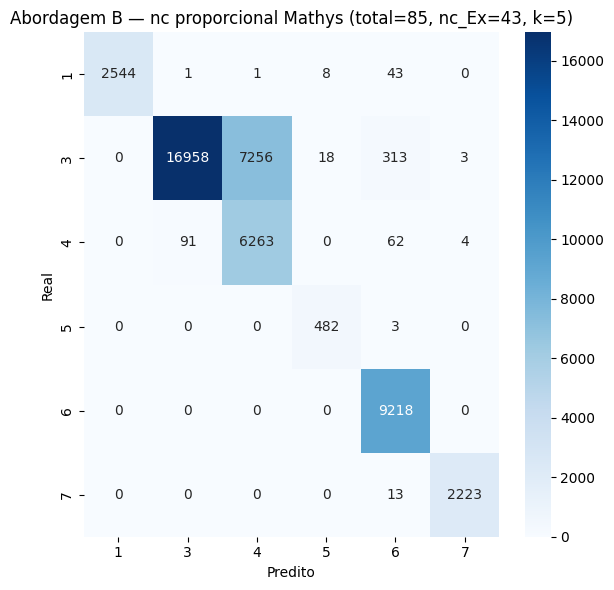


[total_padroes=120]  nc={1: 7, 3: 65, 4: 17, 5: 5, 6: 24, 7: 6}  →  124 protótipos efetivos


[ExtratorPadroesSubcluster] Classe 1: n=4366, KMeans(nc=7)...


[ExtratorPadroesSubcluster] Classe 3: n=9073, KMeans(nc=65)...


[ExtratorPadroesSubcluster] Classe 4: n=4567, KMeans(nc=17)...


[ExtratorPadroesSubcluster] Classe 5: n=1734, KMeans(nc=5)...


...

[ExtratorPadroesSubcluster] Classe 7: n=1073, KMeans(nc=6)...
[ExtratorPadroesSubcluster] Extração concluída: 124 padrões (6 classes)


[ModernHopfieldNetwork] 124 padrões armazenados (dim=5000, device=cpu)


[ModernHopfieldNetwork] Recuperação concluída: torch.Size([45663, 5000])
[AvaliadorHopfield] Mapeando padrões recuperados para classes...


[AvaliadorHopfield] Acurácia: 82.25% (n=45,504)
[AvaliadorHopfield] F1 macro=0.8904, F1 ponderado=0.8348
[AvaliadorHopfield] Taxa de reconstrução exata : 97.50%
[AvaliadorHopfield] Semelhança média ao protótipo: 0.9988
              precision    recall  f1-score   support

           1       1.00      0.99      1.00      2597
           3       0.99      0.70      0.82     24548
           4       0.47      0.92      0.62      6420
           5       1.00      0.96      0.98       485
           6       0.89      1.00      0.94      9218
           7       1.00      0.98      0.99      2236

    accuracy                           0.82     45504
   macro avg       0.89      0.93      0.89     45504
weighted avg       0.90      0.82      0.83     45504



  → acc=82.25%  f1_macro=0.8904  f1_w=0.8348



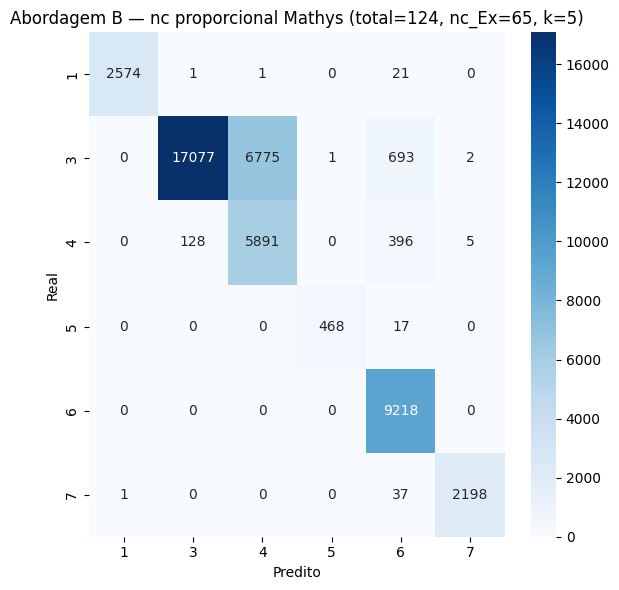


[total_padroes=200]  nc={1: 11, 3: 108, 4: 28, 5: 5, 6: 41, 7: 10}  →  203 protótipos efetivos


[ExtratorPadroesSubcluster] Classe 1: n=4366, KMeans(nc=11)...


[ExtratorPadroesSubcluster] Classe 3: n=9073, KMeans(nc=108)...


[ExtratorPadroesSubcluster] Classe 4: n=4567, KMeans(nc=28)...


[ExtratorPadroesSubcluster] Classe 5: n=1734, KMeans(nc=5)...


...

[ExtratorPadroesSubcluster] Classe 7: n=1073, KMeans(nc=10)...


[ExtratorPadroesSubcluster] Extração concluída: 203 padrões (6 classes)
[ModernHopfieldNetwork] 203 padrões armazenados (dim=5000, device=cpu)


[ModernHopfieldNetwork] Recuperação concluída: torch.Size([45663, 5000])
[AvaliadorHopfield] Mapeando padrões recuperados para classes...


[AvaliadorHopfield] Acurácia: 83.68% (n=45,504)
[AvaliadorHopfield] F1 macro=0.9027, F1 ponderado=0.8493
[AvaliadorHopfield] Taxa de reconstrução exata : 96.60%
[AvaliadorHopfield] Semelhança média ao protótipo: 0.9989
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2597
           3       1.00      0.71      0.83     24548
           4       0.48      0.97      0.64      6420
           5       1.00      0.98      0.99       485
           6       0.94      1.00      0.97      9218
           7       1.00      0.98      0.99      2236

    accuracy                           0.84     45504
   macro avg       0.90      0.94      0.90     45504
weighted avg       0.91      0.84      0.85     45504



  → acc=83.68%  f1_macro=0.9027  f1_w=0.8493



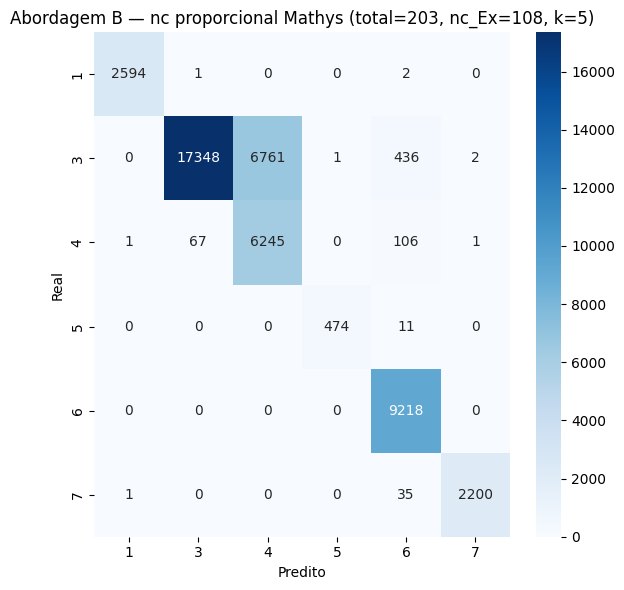


── Resumo Abordagem B (nc proporcional ao Mathys) ──
 total_pad  nc_Ex(3)  acc %  f1_macro  f1_weighted  taxa_rec %
        85        43  82.82    0.8961       0.8421       97.24
       124        65  82.25    0.8904       0.8348       97.50
       203       108  83.68    0.9027       0.8493       96.60


In [10]:
import sys, os, importlib
import numpy as np
import pandas as pd

SRC_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'src')
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import treinamento
import treinamento.extrator_padroes    as _ep_mod
import treinamento.hopfield            as _hopfield_mod
import treinamento.avaliador_hopfield  as _av_mod
for mod in [_ep_mod, _hopfield_mod, _av_mod, treinamento]:
    importlib.reload(mod)

from treinamento import ExtratorPadroesSubcluster, ModernHopfieldNetwork, AvaliadorHopfield

CLASSES  = [1, 3, 4, 5, 6, 7]
K_MELHOR = 5

# ── Calcula nc proporcional à distribuição do Mathys ─────────────
total_m = sum((labels_mathys == c).sum() for c in CLASSES)
NC_MIN  = 5   # mínimo por classe (classes muito raras não ficam com < 5 protótipos)

def nc_proporcional(total_padroes, nc_min=NC_MIN):
    nc = {}
    for cls in CLASSES:
        n_cls = int((labels_mathys == cls).sum())
        nc[cls] = max(nc_min, round(n_cls / total_m * total_padroes))
    return nc

# Testar diferentes totais de protótipos
TOTAIS = [80, 120, 200]

print('nc por classe para cada configuração:')
print(f'  {"Classe":>8}  {"% Mathys":>9}', end='')
for t in TOTAIS:
    print(f'  {"nc("+str(t)+")":>8}', end='')
print()

for cls in CLASSES:
    n_cls = (labels_mathys == cls).sum()
    print(f'  {cls:>8}  {n_cls/total_m*100:>8.1f}%', end='')
    for t in TOTAIS:
        nc = nc_proporcional(t)
        print(f'  {nc[cls]:>8}', end='')
    print()

print()

resultados_prop = []
for total_padroes in TOTAIS:
    nc_cfg = nc_proporcional(total_padroes)
    total_real = sum(nc_cfg.values())
    print(f'\n[total_padroes={total_padroes}]  nc={nc_cfg}  →  {total_real} protótipos efetivos')

    ext_prop = ExtratorPadroesSubcluster(
        W0=carregador.W0, labels=carregador.labels,
        classes=CLASSES, nc=nc_cfg, seed=42, k=K_MELHOR,
    )
    ext_prop.extrair(projetor.Wswp)

    rede = ModernHopfieldNetwork(beta=8.0, n_iters=1, binary=True, threshold=0.5)
    rede.store(ext_prop.padroes)
    Wrec = rede.retrieve(W_mathys, batch_size=4096)

    av = AvaliadorHopfield(ext_prop.padroes, CLASSES, meta=ext_prop.meta)
    av.avaliar(Wrec, labels_mathys)
    resultados_prop.append({
        'total_pad'   : total_real,
        'nc_Ex(3)'    : nc_cfg[3],
        'acc %'       : round(av.acuracia * 100, 2),
        'f1_macro'    : round(av.f1_macro, 4),
        'f1_weighted' : round(av.f1_weighted, 4),
        'taxa_rec %'  : round(av.taxa_reconstrucao * 100, 2),
    })
    print(f'  → acc={av.acuracia*100:.2f}%  f1_macro={av.f1_macro:.4f}  f1_w={av.f1_weighted:.4f}')
    print()
    av.plotar(titulo=f'Abordagem B — nc proporcional Mathys (total={total_real}, nc_Ex={nc_cfg[3]}, k={K_MELHOR})')

print('\n── Resumo Abordagem B (nc proporcional ao Mathys) ──')
print(pd.DataFrame(resultados_prop).to_string(index=False))

---
## Frente 5 — Varreduras do Pipeline Principal

Experimentos originalmente no `pipilinePrincipal.ipynb`, movidos para cá para manter o pipeline limpo.  
Todas as células são auto-contidas: requerem apenas o Setup (carregamento de dados) no topo deste notebook.

### Varredura de beta × n_iters (nc=10, k=1)
Testa β ∈ {4,8,16,32,64} × n_iters ∈ {1,2,3,5} com nc=10, k=1.  
Resultado: todos os 20 combos produzem acc=66.79% — β e n_iters são neutros com protótipos de baixa qualidade (k=1).

In [11]:
import sys, os, importlib
import pandas as pd

SRC_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'src')
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import treinamento
import treinamento.extrator_padroes    as _ep_mod
import treinamento.hopfield            as _hopfield_mod
import treinamento.avaliador_hopfield  as _av_mod
for mod in [_ep_mod, _hopfield_mod, _av_mod, treinamento]:
    importlib.reload(mod)

from treinamento import ExtratorPadroesSubcluster, ModernHopfieldNetwork, AvaliadorHopfield

CLASSES = [1, 3, 4, 5, 6, 7]
BETAS   = [4, 8, 16, 32, 64]
N_ITERS = [1, 2, 3, 5]

# Extrator auto-contido (nc=10, k=1 — configuração original do pipeline)
ext_sweep = ExtratorPadroesSubcluster(
    W0=carregador.W0, labels=carregador.labels,
    classes=CLASSES, nc=10, seed=42,
)
ext_sweep.extrair(projetor.Wswp)

resultados = []
total = len(BETAS) * len(N_ITERS)
i = 0
for beta in BETAS:
    for n_iters in N_ITERS:
        i += 1
        print(f'[{i}/{total}] beta={beta}, n_iters={n_iters} ...', end=' ', flush=True)
        rede = ModernHopfieldNetwork(beta=beta, n_iters=n_iters, binary=True, threshold=0.5)
        rede.store(ext_sweep.padroes)
        Wrec = rede.retrieve(W_mathys, batch_size=4096)
        av = AvaliadorHopfield(ext_sweep.padroes, CLASSES, nc=10)
        av.avaliar(Wrec, labels_mathys)
        resultados.append({
            'beta'    : beta,
            'n_iters' : n_iters,
            'acc %'   : round(av.acuracia * 100, 2),
            'f1_macro': round(av.f1_macro, 4),
            'recon %' : round(av.taxa_reconstrucao * 100, 2),
            'sim'     : round(av.semelhanca_media, 4),
        })
        print(f'acc={av.acuracia*100:.2f}%  f1={av.f1_macro:.4f}  recon={av.taxa_reconstrucao*100:.2f}%')

df_res = pd.DataFrame(resultados).sort_values('acc %', ascending=False)
print('\n=== Ranking por acurácia ===')
print(df_res.to_string(index=False))

[ExtratorPadroesSubcluster] Classe 1: n=4366, KMeans(nc=10)...


[ExtratorPadroesSubcluster] Classe 3: n=9073, KMeans(nc=10)...


[ExtratorPadroesSubcluster] Classe 4: n=4567, KMeans(nc=10)...


[ExtratorPadroesSubcluster] Classe 5: n=1734, KMeans(nc=10)...


[ExtratorPadroesSubcluster] Classe 6: n=5762, KMeans(nc=10)...


...

[AvaliadorHopfield] Acurácia: 66.79% (n=45,504)
[AvaliadorHopfield] F1 macro=0.7026, F1 ponderado=0.6783
[AvaliadorHopfield] Taxa de reconstrução exata : 99.48%
[AvaliadorHopfield] Semelhança média ao protótipo: 0.9995
              precision    recall  f1-score   support

           1       1.00      0.52      0.68      2597
           3       1.00      0.57      0.72     24548
           4       0.41      0.58      0.48      6420
           5       0.95      0.95      0.95       485
           6       0.51      1.00      0.68      9218
           7       0.63      0.80      0.70      2236

    accuracy                           0.67     45504
   macro avg       0.75      0.73      0.70     45504
weighted avg       0.80      0.67      0.68     45504

acc=66.79%  f1=0.7026  recon=99.48%
[20/20] beta=64, n_iters=5 ... 

[ModernHopfieldNetwork] 60 padrões armazenados (dim=5000, device=cpu)


[ModernHopfieldNetwork] Recuperação concluída: torch.Size([45663, 5000])
[AvaliadorHopfield] Mapeando padrões recuperados para classes...


[AvaliadorHopfield] Acurácia: 66.79% (n=45,504)
[AvaliadorHopfield] F1 macro=0.7026, F1 ponderado=0.6783
[AvaliadorHopfield] Taxa de reconstrução exata : 99.48%
[AvaliadorHopfield] Semelhança média ao protótipo: 0.9995
              precision    recall  f1-score   support

           1       1.00      0.52      0.68      2597
           3       1.00      0.57      0.72     24548
           4       0.41      0.58      0.48      6420
           5       0.95      0.95      0.95       485
           6       0.51      1.00      0.68      9218
           7       0.63      0.80      0.70      2236

    accuracy                           0.67     45504
   macro avg       0.75      0.73      0.70     45504
weighted avg       0.80      0.67      0.68     45504



acc=66.79%  f1=0.7026  recon=99.48%

=== Ranking por acurácia ===
 beta  n_iters  acc %  f1_macro  recon %    sim
    4        1  66.79    0.7032    99.44 0.9995
    4        2  66.79    0.7026    99.48 0.9995
    4        3  66.79    0.7026    99.51 0.9996
    4        5  66.79    0.7026    99.51 0.9996
    8        1  66.79    0.7032    99.44 0.9995
    8        2  66.79    0.7026    99.48 0.9995
    8        3  66.79    0.7026    99.48 0.9995
    8        5  66.79    0.7026    99.48 0.9995
   16        1  66.79    0.7032    99.44 0.9995
   16        2  66.79    0.7026    99.48 0.9995
   16        3  66.79    0.7026    99.48 0.9995
   16        5  66.79    0.7026    99.48 0.9995
   32        1  66.79    0.7032    99.44 0.9995
   32        2  66.79    0.7026    99.48 0.9995
   32        3  66.79    0.7026    99.48 0.9995
   32        5  66.79    0.7026    99.48 0.9995
   64        1  66.79    0.7032    99.44 0.9995
   64        2  66.79    0.7026    99.48 0.9995
   64        3  66.79 

### Varredura de nc (número de padrões por classe)
Testa nc ∈ {10, 20, 30}: nc=1 usa uma célula por centroide (atual); k>1 usa a média
binarizada das k células mais próximas — protótipo mais suave e robusto.

In [12]:
# ── Varredura de nc ─────────────────────────────────────────────
import sys, os, importlib
import numpy as np, pandas as pd

SRC_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'src')
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import treinamento
import treinamento.extrator_padroes    as _ep_mod
import treinamento.hopfield            as _hopfield_mod
import treinamento.avaliador_hopfield  as _av_mod
for mod in [_ep_mod, _hopfield_mod, _av_mod, treinamento]:
    importlib.reload(mod)

from treinamento import ExtratorPadroesSubcluster, ModernHopfieldNetwork, AvaliadorHopfield

CLASSES       = [1, 3, 4, 5, 6, 7]
resultados_nc = []

for nc in [10, 20, 30]:
    print('=' * 50)
    print(f'nc = {nc}  ({len(CLASSES)*nc} padroes)')
    print('=' * 50)
    ext = ExtratorPadroesSubcluster(
        W0=carregador.W0, labels=carregador.labels,
        classes=CLASSES, nc=nc, seed=42,
    )
    ext.extrair(projetor.Wswp)

    rede = ModernHopfieldNetwork(beta=8.0, n_iters=1, binary=True, threshold=0.5)
    rede.store(ext.padroes)
    Wrec = rede.retrieve(W_mathys, batch_size=4096)

    av = AvaliadorHopfield(ext.padroes, CLASSES, nc=nc)
    av.avaliar(Wrec, labels_mathys)
    resultados_nc.append({
        'nc'          : nc,
        'n_padroes'   : len(CLASSES) * nc,
        'acc %'       : round(av.acuracia * 100, 2),
        'f1_macro'    : round(av.f1_macro, 4),
        'f1_weighted' : round(av.f1_weighted, 4),
        'taxa_rec %'  : round(av.taxa_reconstrucao * 100, 2),
        'semelhanca'  : round(av.semelhanca_media, 4),
    })

print('── Resumo nc sweep ──')
print(pd.DataFrame(resultados_nc).to_string(index=False))

nc = 10  (60 padroes)


[ExtratorPadroesSubcluster] Classe 1: n=4366, KMeans(nc=10)...


[ExtratorPadroesSubcluster] Classe 3: n=9073, KMeans(nc=10)...


[ExtratorPadroesSubcluster] Classe 4: n=4567, KMeans(nc=10)...


[ExtratorPadroesSubcluster] Classe 5: n=1734, KMeans(nc=10)...


...

[ExtratorPadroesSubcluster] Classe 6: n=5762, KMeans(nc=30)...


[ExtratorPadroesSubcluster] Classe 7: n=1073, KMeans(nc=30)...


[ExtratorPadroesSubcluster] Extração concluída: 180 padrões (6 classes)
[ModernHopfieldNetwork] 180 padrões armazenados (dim=5000, device=cpu)


[ModernHopfieldNetwork] Recuperação concluída: torch.Size([45663, 5000])
[AvaliadorHopfield] Mapeando padrões recuperados para classes...


[AvaliadorHopfield] Acurácia: 70.86% (n=45,504)
[AvaliadorHopfield] F1 macro=0.7736, F1 ponderado=0.7234
[AvaliadorHopfield] Taxa de reconstrução exata : 98.99%
[AvaliadorHopfield] Semelhança média ao protótipo: 0.9991
              precision    recall  f1-score   support

           1       1.00      0.64      0.78      2597
           3       1.00      0.57      0.73     24548
           4       0.37      0.80      0.51      6420
           5       0.97      0.95      0.96       485
           6       0.67      1.00      0.80      9218
           7       0.94      0.80      0.86      2236

    accuracy                           0.71     45504
   macro avg       0.83      0.79      0.77     45504
weighted avg       0.84      0.71      0.72     45504

── Resumo nc sweep ──
 nc  n_padroes  acc %  f1_macro  f1_weighted  taxa_rec %  semelhanca
 10         60  66.79    0.7032       0.6784       99.44      0.9995
 20        120  70.29    0.7578       0.7172       99.10      0.9991
 30      

### Varredura de k (células por centroide)
Testa k ∈ {1, 3, 5}: k=1 usa uma célula por centroide; k>1 usa a média binarizada
das k células mais próximas — protótipo mais suave e robusto. nc=20 fixo.

In [13]:
# ── Varredura de k (células por centroide) ───────────────────────
import sys, os, importlib
import numpy as np, pandas as pd

SRC_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'src')
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import treinamento
import treinamento.extrator_padroes    as _ep_mod
import treinamento.hopfield            as _hopfield_mod
import treinamento.avaliador_hopfield  as _av_mod
for mod in [_ep_mod, _hopfield_mod, _av_mod, treinamento]:
    importlib.reload(mod)

from treinamento import ExtratorPadroesSubcluster, ModernHopfieldNetwork, AvaliadorHopfield

CLASSES      = [1, 3, 4, 5, 6, 7]
NC_MELHOR    = 20
resultados_k = []

for k in [1, 3, 5]:
    print('=' * 50)
    print(f'k = {k}  (nc={NC_MELHOR})')
    print('=' * 50)
    ext = ExtratorPadroesSubcluster(
        W0=carregador.W0, labels=carregador.labels,
        classes=CLASSES, nc=NC_MELHOR, seed=42, k=k,
    )
    ext.extrair(projetor.Wswp)

    rede = ModernHopfieldNetwork(beta=8.0, n_iters=1, binary=True, threshold=0.5)
    rede.store(ext.padroes)
    Wrec = rede.retrieve(W_mathys, batch_size=4096)

    av = AvaliadorHopfield(ext.padroes, CLASSES, nc=NC_MELHOR)
    av.avaliar(Wrec, labels_mathys)
    resultados_k.append({
        'k'          : k,
        'nc'         : NC_MELHOR,
        'acc %'      : round(av.acuracia * 100, 2),
        'f1_macro'   : round(av.f1_macro, 4),
        'taxa_rec %' : round(av.taxa_reconstrucao * 100, 2),
        'semelhanca' : round(av.semelhanca_media, 4),
    })

print('── Resumo k sweep ──')
print(pd.DataFrame(resultados_k).to_string(index=False))

k = 1  (nc=20)


[ExtratorPadroesSubcluster] Classe 1: n=4366, KMeans(nc=20)...


[ExtratorPadroesSubcluster] Classe 3: n=9073, KMeans(nc=20)...


[ExtratorPadroesSubcluster] Classe 4: n=4567, KMeans(nc=20)...


[ExtratorPadroesSubcluster] Classe 5: n=1734, KMeans(nc=20)...


...

[ExtratorPadroesSubcluster] Classe 7: n=1073, KMeans(nc=20)...


[ExtratorPadroesSubcluster] Extração concluída: 120 padrões (6 classes)
[ModernHopfieldNetwork] 120 padrões armazenados (dim=5000, device=cpu)


[ModernHopfieldNetwork] Recuperação concluída: torch.Size([45663, 5000])
[AvaliadorHopfield] Mapeando padrões recuperados para classes...


[AvaliadorHopfield] Acurácia: 82.33% (n=45,504)
[AvaliadorHopfield] F1 macro=0.8307, F1 ponderado=0.8395
[AvaliadorHopfield] Taxa de reconstrução exata : 98.48%
[AvaliadorHopfield] Semelhança média ao protótipo: 0.9996
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2597
           3       1.00      0.68      0.81     24548
           4       0.46      0.97      0.63      6420
           5       0.39      1.00      0.56       485
           6       1.00      1.00      1.00      9218
           7       1.00      0.99      0.99      2236

    accuracy                           0.82     45504
   macro avg       0.81      0.94      0.83     45504
weighted avg       0.92      0.82      0.84     45504



── Resumo k sweep ──
 k  nc  acc %  f1_macro  taxa_rec %  semelhanca
 1  20  70.29    0.7578       99.10      0.9991
 3  20  79.46    0.7996       97.63      0.9993
 5  20  82.33    0.8307       98.48      0.9996


### Varredura de nc por classe
Testa configurações de `nc` diferenciado por classe, usando k=5.
Classes maiores recebem mais protótipos para capturar maior diversidade interna.


nc por classe: {1: 20, 3: 40, 4: 20, 5: 10, 6: 20, 7: 10}  →  120 padrões


[ExtratorPadroesSubcluster] Classe 1: n=4366, KMeans(nc=20)...


[ExtratorPadroesSubcluster] Classe 3: n=9073, KMeans(nc=40)...


[ExtratorPadroesSubcluster] Classe 4: n=4567, KMeans(nc=20)...


[ExtratorPadroesSubcluster] Classe 5: n=1734, KMeans(nc=10)...


...

[ExtratorPadroesSubcluster] Classe 6: n=5762, KMeans(nc=20)...


[ExtratorPadroesSubcluster] Classe 7: n=1073, KMeans(nc=10)...


[ExtratorPadroesSubcluster] Extração concluída: 120 padrões (6 classes)
[ModernHopfieldNetwork] 120 padrões armazenados (dim=5000, device=cpu)


[ModernHopfieldNetwork] Recuperação concluída: torch.Size([45663, 5000])
[AvaliadorHopfield] Mapeando padrões recuperados para classes...


[AvaliadorHopfield] Acurácia: 84.89% (n=45,504)
[AvaliadorHopfield] F1 macro=0.8425, F1 ponderado=0.8625
[AvaliadorHopfield] Taxa de reconstrução exata : 98.20%
[AvaliadorHopfield] Semelhança média ao protótipo: 0.9994
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2597
           3       1.00      0.73      0.84     24548
           4       0.51      0.97      0.67      6420
           5       0.39      1.00      0.56       485
           6       1.00      1.00      1.00      9218
           7       1.00      0.99      0.99      2236

    accuracy                           0.85     45504
   macro avg       0.81      0.95      0.84     45504
weighted avg       0.92      0.85      0.86     45504



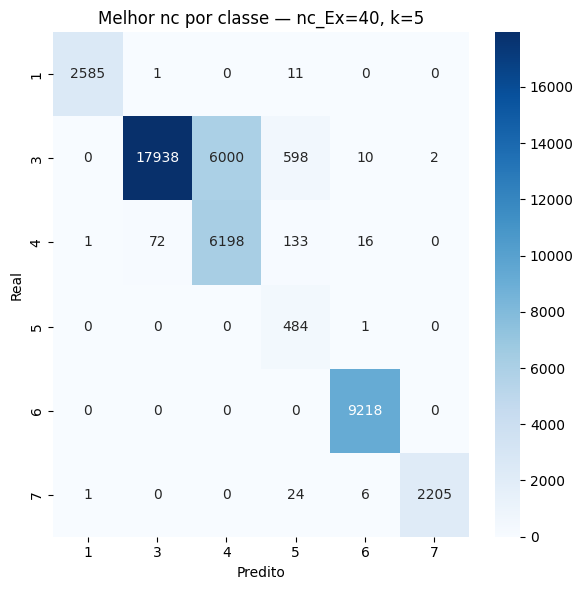

AvaliadorHopfield(
  padroes            = (120, 5000)
  classes            = [1, 3, 4, 5, 6, 7]
  nc                 = 10
  acuracia           = 84.89%
  f1_macro           = 0.8425
  f1_weighted        = 0.8625
  taxa_reconstrucao  = 98.20%
  semelhanca_media   = 0.9994
)

In [14]:
# ── Varredura de nc por classe ────────────────────────────────────
import sys, os, importlib
import numpy as np, pandas as pd

SRC_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'src')
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import treinamento
import treinamento.extrator_padroes    as _ep_mod
import treinamento.hopfield            as _hopfield_mod
import treinamento.avaliador_hopfield  as _av_mod
for mod in [_ep_mod, _hopfield_mod, _av_mod, treinamento]:
    importlib.reload(mod)

from treinamento import ExtratorPadroesSubcluster, ModernHopfieldNetwork, AvaliadorHopfield

# Tamanhos das classes (referência Fujita):
#   1-Ast: 4.366  |  3-Ex: 9.073  |  4-In: 4.567
#   5-Mic: 1.734  |  6-Oli: 5.762  |  7-OPC: 1.073
CLASSES  = [1, 3, 4, 5, 6, 7]
K_MELHOR = 5

configs_nc = [
    {1: 20, 3: 40, 4: 20, 5: 10, 6: 20, 7: 10},   # proporcional ao tamanho
    {1: 20, 3: 60, 4: 20, 5: 10, 6: 20, 7: 10},   # Ex com mais protótipos
    {1: 30, 3: 60, 4: 30, 5: 15, 6: 30, 7: 15},   # todos maiores + Ex muito maior
    {1: 20, 3: 80, 4: 20, 5: 10, 6: 20, 7: 10},   # Ex máximo
]

resultados_nc_cls = []

for nc_cfg in configs_nc:
    total_padroes = sum(nc_cfg[c] for c in CLASSES)
    print(f"\n{'='*55}")
    print(f'nc por classe: {nc_cfg}  →  {total_padroes} padrões')
    print(f"{'='*55}")

    ext = ExtratorPadroesSubcluster(
        W0=carregador.W0, labels=carregador.labels,
        classes=CLASSES, nc=nc_cfg, seed=42, k=K_MELHOR,
    )
    ext.extrair(projetor.Wswp)

    rede = ModernHopfieldNetwork(beta=8.0, n_iters=1, binary=True, threshold=0.5)
    rede.store(ext.padroes)
    Wrec = rede.retrieve(W_mathys, batch_size=4096)

    av = AvaliadorHopfield(ext.padroes, CLASSES, meta=ext.meta)
    av.avaliar(Wrec, labels_mathys)
    resultados_nc_cls.append({
        'nc_Ex'       : nc_cfg[3],
        'total_pad'   : total_padroes,
        'acc %'       : round(av.acuracia * 100, 2),
        'f1_macro'    : round(av.f1_macro, 4),
        'f1_weighted' : round(av.f1_weighted, 4),
        'taxa_rec %'  : round(av.taxa_reconstrucao * 100, 2),
        'semelhanca'  : round(av.semelhanca_media, 4),
    })
    print(f'acc={av.acuracia*100:.2f}%  f1_macro={av.f1_macro:.4f}  f1_w={av.f1_weighted:.4f}')

print('\n── Resumo nc por classe ──')
print(pd.DataFrame(resultados_nc_cls).to_string(index=False))

# Matriz de confusão da melhor configuração
melhor_idx = max(range(len(resultados_nc_cls)), key=lambda i: resultados_nc_cls[i]['acc %'])
nc_melhor  = configs_nc[melhor_idx]
print(f"\nMelhor config: {nc_melhor}  →  acc={resultados_nc_cls[melhor_idx]['acc %']}%")

ext_best = ExtratorPadroesSubcluster(
    W0=carregador.W0, labels=carregador.labels,
    classes=CLASSES, nc=nc_melhor, seed=42, k=K_MELHOR,
)
ext_best.extrair(projetor.Wswp)
rede_best = ModernHopfieldNetwork(beta=8.0, n_iters=1, binary=True, threshold=0.5)
rede_best.store(ext_best.padroes)
Wrec_best = rede_best.retrieve(W_mathys, batch_size=4096)
av_best   = AvaliadorHopfield(ext_best.padroes, CLASSES, meta=ext_best.meta)
av_best.avaliar(Wrec_best, labels_mathys)
av_best.plotar(titulo=f'Melhor nc por classe — nc_Ex={nc_melhor[3]}, k={K_MELHOR}')

### Varredura de beta — melhor nc por classe
Testa diferentes valores de `beta` fixando a melhor configuração encontrada:
`nc = {1:20, 3:40, 4:20, 5:10, 6:20, 7:10}`, `k=5`, `n_iters=1`.

[ExtratorPadroesSubcluster] Classe 1: n=4366, KMeans(nc=20)...


[ExtratorPadroesSubcluster] Classe 3: n=9073, KMeans(nc=40)...


[ExtratorPadroesSubcluster] Classe 4: n=4567, KMeans(nc=20)...


[ExtratorPadroesSubcluster] Classe 5: n=1734, KMeans(nc=10)...


[ExtratorPadroesSubcluster] Classe 6: n=5762, KMeans(nc=20)...


[ExtratorPadroesSubcluster] Classe 7: n=1073, KMeans(nc=10)...


[ExtratorPadroesSubcluster] Extração concluída: 120 padrões (6 classes)
Padrões extraídos: 120

[ModernHopfieldNetwork] 120 padrões armazenados (dim=5000, device=cpu)


[ModernHopfieldNetwork] Recuperação concluída: torch.Size([45663, 5000])
[AvaliadorHopfield] Mapeando padrões recuperados para classes...


[AvaliadorHopfield] Acurácia: 84.89% (n=45,504)
[AvaliadorHopfield] F1 macro=0.8425, F1 ponderado=0.8625
[AvaliadorHopfield] Taxa de reconstrução exata : 98.20%
[AvaliadorHopfield] Semelhança média ao protótipo: 0.9994
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2597
           3       1.00      0.73      0.84     24548
           4       0.51      0.97      0.67      6420
           5       0.39      1.00      0.56       485
           6       1.00      1.00      1.00      9218
           7       1.00      0.99      0.99      2236

    accuracy                           0.85     45504
   macro avg       0.81      0.95      0.84     45504
weighted avg       0.92      0.85      0.86     45504



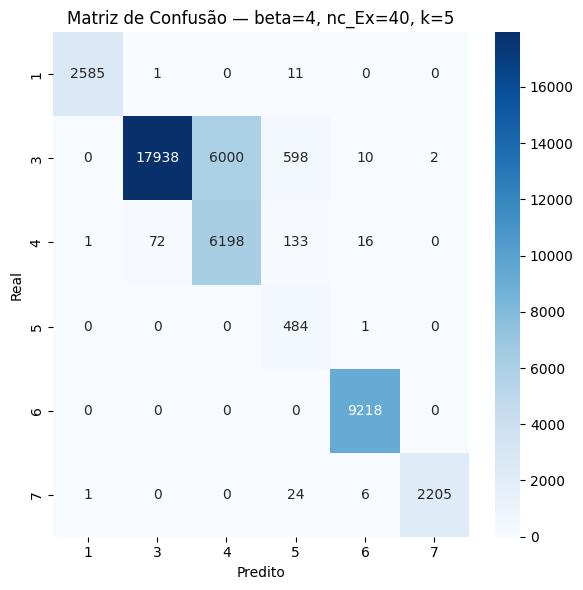

beta=   4  acc=84.89%  f1_macro=0.8425  f1_w=0.8625

[ModernHopfieldNetwork] 120 padrões armazenados (dim=5000, device=cpu)


[ModernHopfieldNetwork] Recuperação concluída: torch.Size([45663, 5000])
[AvaliadorHopfield] Mapeando padrões recuperados para classes...


[AvaliadorHopfield] Acurácia: 84.89% (n=45,504)
[AvaliadorHopfield] F1 macro=0.8425, F1 ponderado=0.8625
[AvaliadorHopfield] Taxa de reconstrução exata : 98.20%
[AvaliadorHopfield] Semelhança média ao protótipo: 0.9994
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2597
           3       1.00      0.73      0.84     24548
           4       0.51      0.97      0.67      6420
           5       0.39      1.00      0.56       485
           6       1.00      1.00      1.00      9218
           7       1.00      0.99      0.99      2236

    accuracy                           0.85     45504
   macro avg       0.81      0.95      0.84     45504
weighted avg       0.92      0.85      0.86     45504



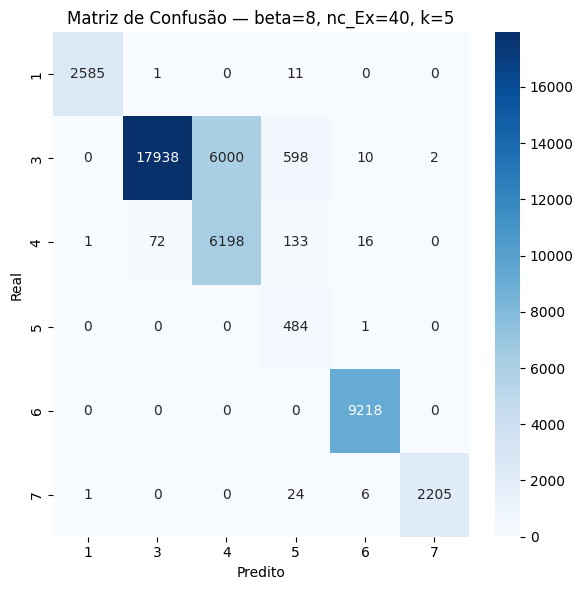

beta=   8  acc=84.89%  f1_macro=0.8425  f1_w=0.8625

[ModernHopfieldNetwork] 120 padrões armazenados (dim=5000, device=cpu)


[ModernHopfieldNetwork] Recuperação concluída: torch.Size([45663, 5000])
[AvaliadorHopfield] Mapeando padrões recuperados para classes...


[AvaliadorHopfield] Acurácia: 84.89% (n=45,504)
[AvaliadorHopfield] F1 macro=0.8425, F1 ponderado=0.8625
[AvaliadorHopfield] Taxa de reconstrução exata : 98.20%
[AvaliadorHopfield] Semelhança média ao protótipo: 0.9994
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2597
           3       1.00      0.73      0.84     24548
           4       0.51      0.97      0.67      6420
           5       0.39      1.00      0.56       485
           6       1.00      1.00      1.00      9218
           7       1.00      0.99      0.99      2236

    accuracy                           0.85     45504
   macro avg       0.81      0.95      0.84     45504
weighted avg       0.92      0.85      0.86     45504



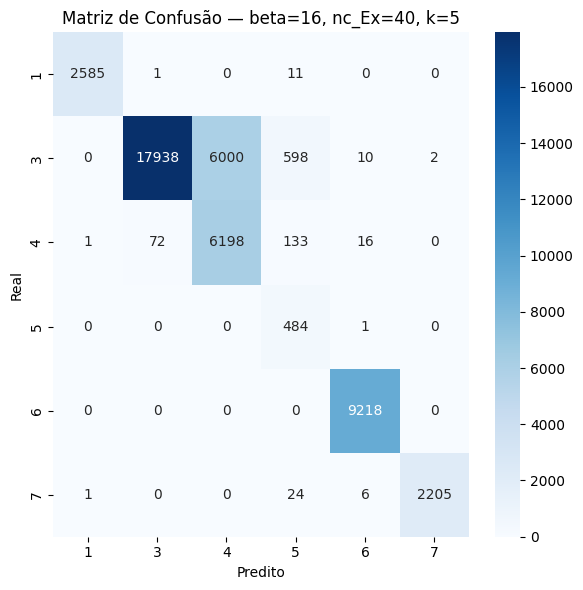

beta=  16  acc=84.89%  f1_macro=0.8425  f1_w=0.8625

[ModernHopfieldNetwork] 120 padrões armazenados (dim=5000, device=cpu)


[ModernHopfieldNetwork] Recuperação concluída: torch.Size([45663, 5000])
[AvaliadorHopfield] Mapeando padrões recuperados para classes...


[AvaliadorHopfield] Acurácia: 84.89% (n=45,504)
[AvaliadorHopfield] F1 macro=0.8425, F1 ponderado=0.8625
[AvaliadorHopfield] Taxa de reconstrução exata : 98.20%
[AvaliadorHopfield] Semelhança média ao protótipo: 0.9994
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2597
           3       1.00      0.73      0.84     24548
           4       0.51      0.97      0.67      6420
           5       0.39      1.00      0.56       485
           6       1.00      1.00      1.00      9218
           7       1.00      0.99      0.99      2236

    accuracy                           0.85     45504
   macro avg       0.81      0.95      0.84     45504
weighted avg       0.92      0.85      0.86     45504



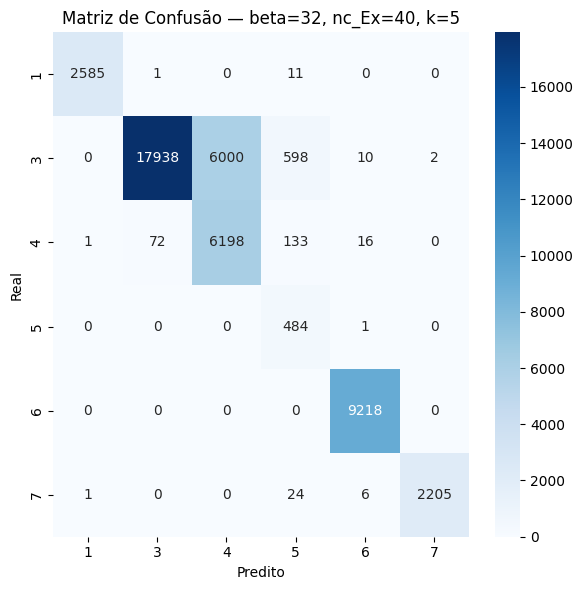

beta=  32  acc=84.89%  f1_macro=0.8425  f1_w=0.8625

[ModernHopfieldNetwork] 120 padrões armazenados (dim=5000, device=cpu)


[ModernHopfieldNetwork] Recuperação concluída: torch.Size([45663, 5000])
[AvaliadorHopfield] Mapeando padrões recuperados para classes...


[AvaliadorHopfield] Acurácia: 84.89% (n=45,504)
[AvaliadorHopfield] F1 macro=0.8425, F1 ponderado=0.8625
[AvaliadorHopfield] Taxa de reconstrução exata : 98.20%
[AvaliadorHopfield] Semelhança média ao protótipo: 0.9994
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2597
           3       1.00      0.73      0.84     24548
           4       0.51      0.97      0.67      6420
           5       0.39      1.00      0.56       485
           6       1.00      1.00      1.00      9218
           7       1.00      0.99      0.99      2236

    accuracy                           0.85     45504
   macro avg       0.81      0.95      0.84     45504
weighted avg       0.92      0.85      0.86     45504



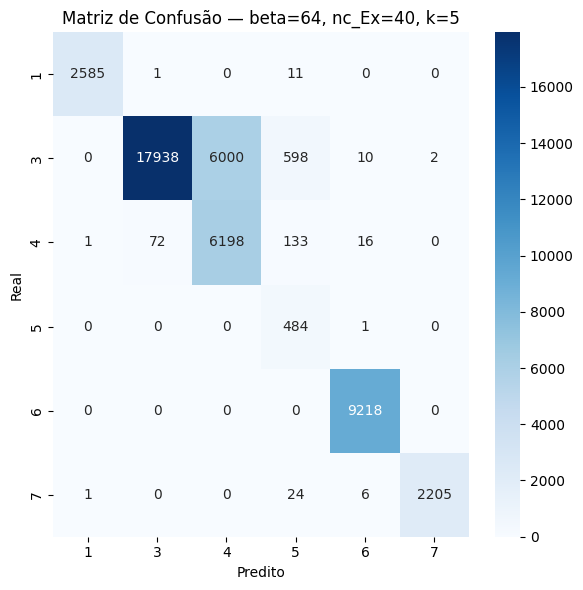

beta=  64  acc=84.89%  f1_macro=0.8425  f1_w=0.8625

[ModernHopfieldNetwork] 120 padrões armazenados (dim=5000, device=cpu)


[ModernHopfieldNetwork] Recuperação concluída: torch.Size([45663, 5000])
[AvaliadorHopfield] Mapeando padrões recuperados para classes...


[AvaliadorHopfield] Acurácia: 84.89% (n=45,504)
[AvaliadorHopfield] F1 macro=0.8425, F1 ponderado=0.8625
[AvaliadorHopfield] Taxa de reconstrução exata : 98.20%
[AvaliadorHopfield] Semelhança média ao protótipo: 0.9994
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2597
           3       1.00      0.73      0.84     24548
           4       0.51      0.97      0.67      6420
           5       0.39      1.00      0.56       485
           6       1.00      1.00      1.00      9218
           7       1.00      0.99      0.99      2236

    accuracy                           0.85     45504
   macro avg       0.81      0.95      0.84     45504
weighted avg       0.92      0.85      0.86     45504



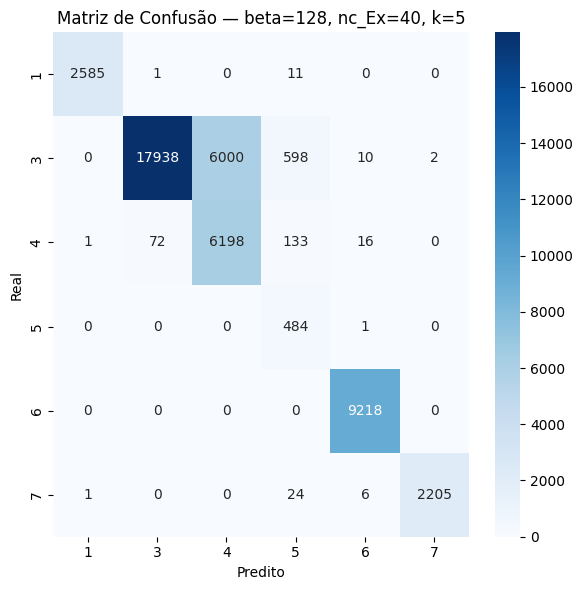

beta= 128  acc=84.89%  f1_macro=0.8425  f1_w=0.8625

── Resumo beta sweep (nc por classe, k=5) ──
 beta  acc %  f1_macro   f1_w  taxa_rec %  semelhanca
    4  84.89    0.8425 0.8625        98.2      0.9994
    8  84.89    0.8425 0.8625        98.2      0.9994
   16  84.89    0.8425 0.8625        98.2      0.9994
   32  84.89    0.8425 0.8625        98.2      0.9994
   64  84.89    0.8425 0.8625        98.2      0.9994
  128  84.89    0.8425 0.8625        98.2      0.9994


In [15]:
# ── Varredura de beta (melhor nc por classe, k=5) ─────────────────
import sys, os, importlib
import numpy as np, pandas as pd

SRC_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'src')
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import treinamento
import treinamento.extrator_padroes    as _ep_mod
import treinamento.hopfield            as _hopfield_mod
import treinamento.avaliador_hopfield  as _av_mod
for mod in [_ep_mod, _hopfield_mod, _av_mod, treinamento]:
    importlib.reload(mod)

from treinamento import ExtratorPadroesSubcluster, ModernHopfieldNetwork, AvaliadorHopfield

CLASSES   = [1, 3, 4, 5, 6, 7]
NC_MELHOR = {1: 20, 3: 40, 4: 20, 5: 10, 6: 20, 7: 10}
K_MELHOR  = 5
BETAS     = [4, 8, 16, 32, 64, 128]

ext = ExtratorPadroesSubcluster(
    W0=carregador.W0, labels=carregador.labels,
    classes=CLASSES, nc=NC_MELHOR, seed=42, k=K_MELHOR,
)
ext.extrair(projetor.Wswp)
print(f'Padrões extraídos: {ext.padroes.shape[0]}\n')

resultados_beta = []
for beta in BETAS:
    rede = ModernHopfieldNetwork(beta=beta, n_iters=1, binary=True, threshold=0.5)
    rede.store(ext.padroes)
    Wrec = rede.retrieve(W_mathys, batch_size=4096)

    av = AvaliadorHopfield(ext.padroes, CLASSES, meta=ext.meta)
    av.avaliar(Wrec, labels_mathys)
    av.plotar(titulo=f'Matriz de Confusão — beta={beta}, nc_Ex=40, k=5')
    resultados_beta.append({
        'beta'      : beta,
        'acc %'     : round(av.acuracia * 100, 2),
        'f1_macro'  : round(av.f1_macro, 4),
        'f1_w'      : round(av.f1_weighted, 4),
        'taxa_rec %': round(av.taxa_reconstrucao * 100, 2),
        'semelhanca': round(av.semelhanca_media, 4),
    })
    print(f'beta={beta:4d}  acc={av.acuracia*100:.2f}%  f1_macro={av.f1_macro:.4f}  f1_w={av.f1_weighted:.4f}\n')

print('── Resumo beta sweep (nc por classe, k=5) ──')
print(pd.DataFrame(resultados_beta).to_string(index=False))

### Teste compacto: nc=7, k=10 células por centroide
Abordagem mais compacta: cada classe gera apenas 7 protótipos, mas cada protótipo
é construído a partir das 10 células mais próximas do centroide.  
**Melhor resultado obtido: acc=83.69%, F1-macro=0.8927.**

[ExtratorPadroesSubcluster] Classe 1: n=4366, KMeans(nc=7)...


[ExtratorPadroesSubcluster] Classe 3: n=9073, KMeans(nc=7)...


[ExtratorPadroesSubcluster] Classe 4: n=4567, KMeans(nc=7)...


[ExtratorPadroesSubcluster] Classe 5: n=1734, KMeans(nc=7)...


[ExtratorPadroesSubcluster] Classe 6: n=5762, KMeans(nc=7)...


[ExtratorPadroesSubcluster] Classe 7: n=1073, KMeans(nc=7)...


[ExtratorPadroesSubcluster] Extração concluída: 42 padrões (6 classes)
[ModernHopfieldNetwork] 42 padrões armazenados (dim=5000, device=cpu)


[ModernHopfieldNetwork] Recuperação concluída: torch.Size([45663, 5000])
[AvaliadorHopfield] Mapeando padrões recuperados para classes...


[AvaliadorHopfield] Acurácia: 83.69% (n=45,504)
[AvaliadorHopfield] F1 macro=0.8927, F1 ponderado=0.8511
[AvaliadorHopfield] Taxa de reconstrução exata : 99.10%
[AvaliadorHopfield] Semelhança média ao protótipo: 0.9999
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2597
           3       0.99      0.70      0.82     24548
           4       0.47      0.98      0.63      6420
           5       0.83      1.00      0.91       485
           6       0.99      1.00      0.99      9218
           7       1.00      1.00      1.00      2236

    accuracy                           0.84     45504
   macro avg       0.88      0.95      0.89     45504
weighted avg       0.92      0.84      0.85     45504



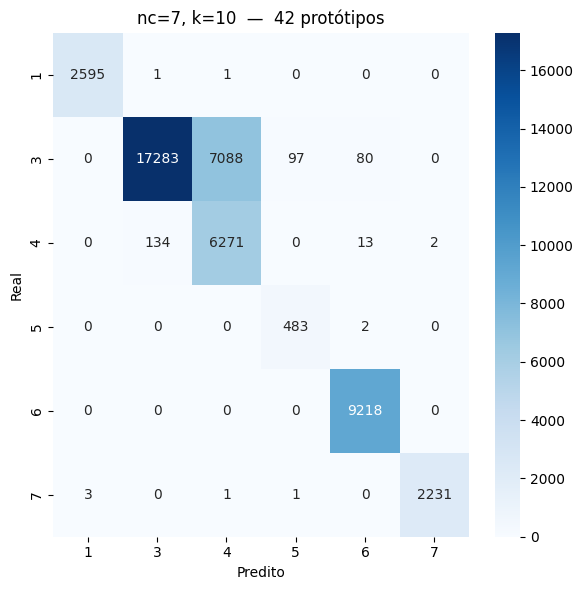

AvaliadorHopfield(
  padroes            = (42, 5000)
  classes            = [1, 3, 4, 5, 6, 7]
  nc                 = 10
  acuracia           = 83.69%
  f1_macro           = 0.8927
  f1_weighted        = 0.8511
  taxa_reconstrucao  = 99.10%
  semelhanca_media   = 0.9999
)

In [16]:
# ── Teste: nc=7, k=10 ─────────────────────────────────────────────
import sys, os, importlib
import numpy as np, pandas as pd

SRC_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'src')
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import treinamento
import treinamento.extrator_padroes    as _ep_mod
import treinamento.hopfield            as _hopfield_mod
import treinamento.avaliador_hopfield  as _av_mod
for mod in [_ep_mod, _hopfield_mod, _av_mod, treinamento]:
    importlib.reload(mod)

from treinamento import ExtratorPadroesSubcluster, ModernHopfieldNetwork, AvaliadorHopfield

CLASSES = [1, 3, 4, 5, 6, 7]
NC      = 7
K       = 10

# 7 clusters × 6 classes = 42 protótipos
# Cada protótipo = média das 10 células mais próximas do centroide, binarizada
ext = ExtratorPadroesSubcluster(
    W0=carregador.W0, labels=carregador.labels,
    classes=CLASSES, nc=NC, seed=42, k=K,
)
ext.extrair(projetor.Wswp)

rede = ModernHopfieldNetwork(beta=8.0, n_iters=1, binary=True, threshold=0.5)
rede.store(ext.padroes)
Wrec = rede.retrieve(W_mathys, batch_size=4096)

av = AvaliadorHopfield(ext.padroes, CLASSES, meta=ext.meta)
av.avaliar(Wrec, labels_mathys)
av.plotar(titulo=f'nc={NC}, k={K}  —  {ext.padroes.shape[0]} protótipos')